In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("HeatSatAI.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9695, 43)


,system:index,Aspect,Elevation,LST,LandCover,NDBI,NDVI,NDWI,Population,Slope,...,Hospital_Distance,School_Distance,Bus_Stop_Distance,Metro_Distance,Commercial_Density,Industrial_Density,Residential_Density,Nighttime_Lights,Emissivity,Albedo
0,0,194.37930,710,33.377997,10,-0.057427,0.580448,-0.582290,5.030181,1.914260,...,5271.708973,3842.524557,453.293584,4698.601731,0,0,0,10.216992,0.988558,0.137514
1,1,251.99329,728,35.767193,40,0.165649,0.299643,-0.508627,2.681274,2.997604,...,6311.290840,5419.751673,1312.711265,6268.907347,0,0,0,3.359685,0.988291,0.169098
2,2,278.53204,739,35.457862,20,0.071885,0.454159,-0.545161,2.737603,6.226889,...,6197.822363,5295.373310,1325.021963,6377.248085,0,0,0,3.359685,0.988144,0.139839
3,3,162.89970,772,36.303822,20,0.130848,0.398837,-0.519787,0.903759,4.840404,...,2880.529745,2554.986649,737.167031,8547.733764,0,0,0,2.538242,0.988089,0.163304
4,4,270.00000,777,35.710795,10,0.066020,0.411111,-0.505388,1.214273,0.475553,...,1905.083242,1826.747521,702.431684,7989.957413,0,0,0,3.409499,0.988080,0.253456


In [5]:
# Dataset overview
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 9695 entries, 0 to 9694
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   system:index                  9695 non-null   int64  
 1   Aspect                        9695 non-null   float64
 2   Elevation                     9695 non-null   int64  
 3   LST                           9695 non-null   float64
 4   LandCover                     9695 non-null   int64  
 5   NDBI                          9695 non-null   float64
 6   NDVI                          9695 non-null   float64
 7   NDWI                          9695 non-null   float64
 8   Population                    9695 non-null   float64
 9   Slope                         9695 non-null   float64
 10  .geo                          9695 non-null   str    
 11  Latitude                      9695 non-null   float64
 12  Longitude                     9695 non-null   float64
 13  Vegetation_Def

In [ ]:
# Target
y = df["LST"]

# Columns to exclude: leaky/unknown-formula, redundant composites, low-value features
drop_columns = [
    "LST", "system:index", ".geo", "Latitude", "Longitude",
    "Heat_Risk_Index", "Urban_Heat_Intensity",   # unknown formula / leaky
    "Building_Density",                           # 43% constant, redundant with NDBI
    "Vegetation_Deficit", "Urbanization_Score", "Vegetation_Cooling_Potential",  # near-duplicate of Water_Cooling_Index
    "Relative_Elevation",                          # duplicate of Elevation_Cooling
    "Water_Influence", "Population_Normalized",    # near-duplicate of Population_Heat_Exposure
]
drop_columns = [c for c in drop_columns if c in df.columns]

X = df.drop(columns=drop_columns)
print("Number of features:", X.shape[1])
print(X.columns.tolist())


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def spatial_block_split(df, block_size_deg=0.01, test_frac=0.2, random_state=42):
    df = df.copy()
    df['block_row'] = (df['Latitude'] // block_size_deg).astype(int)
    df['block_col'] = (df['Longitude'] // block_size_deg).astype(int)
    df['block_id'] = df['block_row'].astype(str) + '_' + df['block_col'].astype(str)

    blocks = np.array(df['block_id'].unique())
    rng = np.random.RandomState(random_state)
    rng.shuffle(blocks)

    n_test_blocks = int(len(blocks) * test_frac)
    test_blocks = set(blocks[:n_test_blocks])
    test_mask = df['block_id'].isin(test_blocks)
    return df[~test_mask], df[test_mask]

train_df, test_df = spatial_block_split(df, block_size_deg=0.01, test_frac=0.2)

X_train = train_df[X.columns]
y_train = train_df["LST"]
X_test = test_df[X.columns]
y_test = test_df["LST"]

print(f"Train: {len(train_df)} rows, {train_df['block_id'].nunique()} blocks")
print(f"Test: {len(test_df)} rows, {test_df['block_id'].nunique()} blocks")


In [16]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\rohit\AppData\Local\Programs\Python\Python312\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


In [20]:
import sklearn
print(sklearn.__version__)

1.9.0


In [21]:
import sys
print(sys.executable)

c:\Users\rohit\AppData\Local\Programs\Python\Python312\python.exe


In [22]:
import sklearn
import xgboost
import lightgbm
import catboost
import shap
import optuna

print("All packages imported successfully!")
print("scikit-learn version:", sklearn.__version__)

c:\Users\rohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


All packages imported successfully!
scikit-learn version: 1.9.0


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Random Forest Trained Successfully!")

✅ Random Forest Trained Successfully!


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
r2 = r2_score(y_test, pred_rf)

print("="*40)
print("Random Forest Results")
print("="*40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Results
MAE  : 0.3372
RMSE : 0.5772
R²   : 0.9294


In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("=" * 50)
print("TRAINING METRICS")
print("=" * 50)
print("R²   :", round(r2_score(y_train, train_pred), 4))
print("MAE  :", round(mean_absolute_error(y_train, train_pred), 4))
print("RMSE :", round(np.sqrt(mean_squared_error(y_train, train_pred)), 4))

print()

print("=" * 50)
print("TESTING METRICS")
print("=" * 50)
print("R²   :", round(r2_score(y_test, test_pred), 4))
print("MAE  :", round(mean_absolute_error(y_test, test_pred), 4))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, test_pred)), 4))

TRAINING METRICS
R²   : 0.9888
MAE  : 0.1261
RMSE : 0.2319

TESTING METRICS
R²   : 0.9294
MAE  : 0.3372
RMSE : 0.5772


In [27]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

print("✅ XGBoost trained successfully!")

✅ XGBoost trained successfully!


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_xgb = xgb.predict(X_test)

print("=" * 40)
print("XGBoost Results")
print("=" * 40)
print("MAE  :", round(mean_absolute_error(y_test, pred_xgb), 4))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_xgb)), 4))
print("R²   :", round(r2_score(y_test, pred_xgb), 4))

XGBoost Results
MAE  : 0.2168
RMSE : 0.3566
R²   : 0.9731


In [29]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return rmse

In [ ]:
from optuna.samplers import TPESampler

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=100)
print("Best RMSE:", study.best_value)
print("Best Parameters:")
print(study.best_params)


In [32]:
best_model = XGBRegressor(
    **study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8798690033520644
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = best_model.predict(X_test)

print("="*40)
print("Optimized XGBoost")
print("="*40)

print("MAE :", round(mean_absolute_error(y_test, pred),4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,pred)),4))
print("R²  :", round(r2_score(y_test,pred),4))

Optimized XGBoost
MAE : 0.207
RMSE: 0.3463
R²  : 0.9746


In [35]:
import joblib

joblib.dump(best_model, "HeatSatAI_XGBoost.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

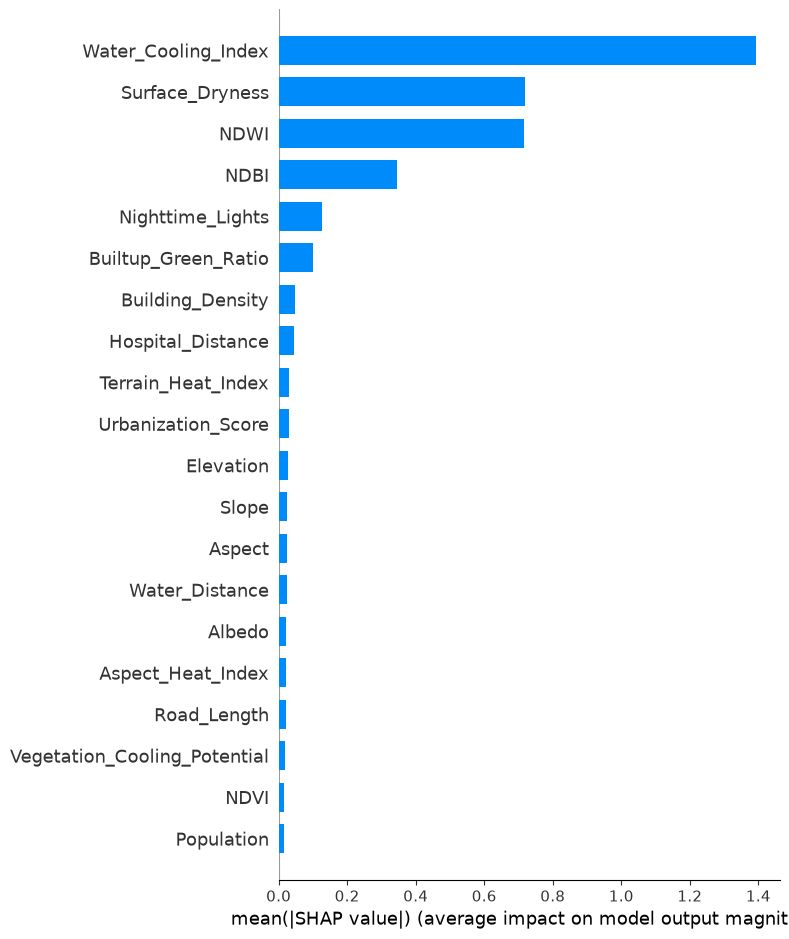

In [37]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

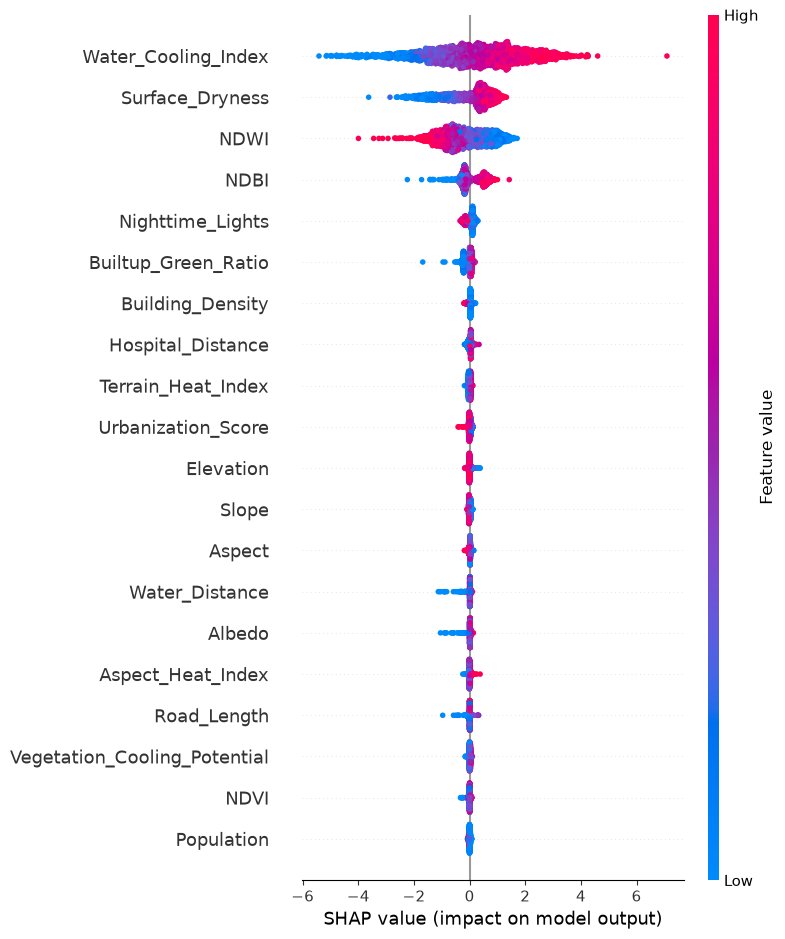

In [38]:
shap.summary_plot(
    shap_values,
    X_test
)

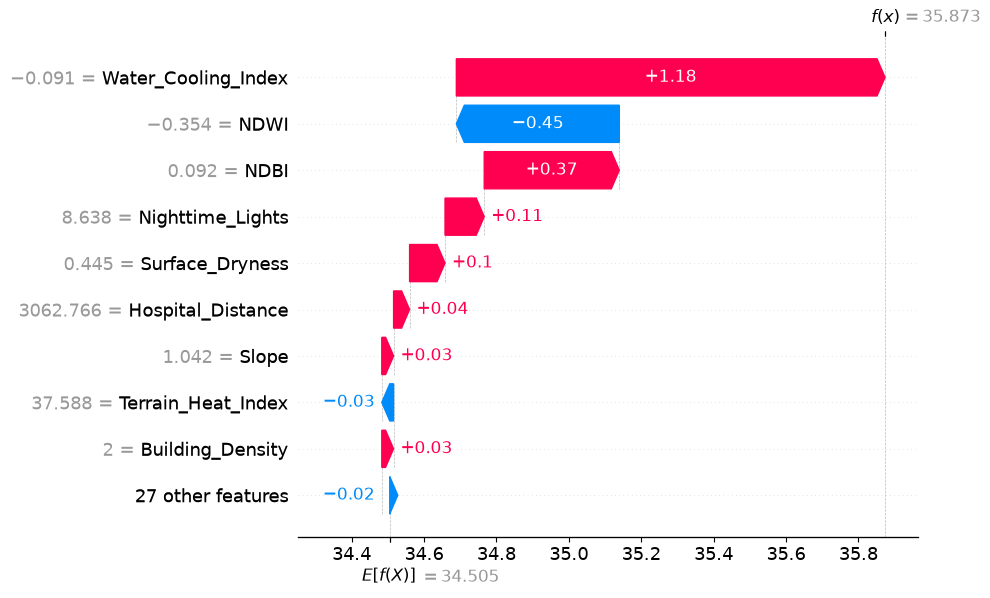

In [39]:
sample = 15

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )
)

In [40]:
importance = best_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance.head(20))

                         Feature  Importance
3                           NDBI    0.247265
11               Surface_Dryness    0.168586
10           Water_Cooling_Index    0.107743
9            Builtup_Green_Ratio    0.093448
33              Nighttime_Lights    0.068407
5                           NDWI    0.048037
21              Building_Density    0.031679
26             Hospital_Distance    0.019692
35                        Albedo    0.016856
24                Water_Distance    0.014657
2                      LandCover    0.013449
32           Residential_Density    0.013012
14             Elevation_Cooling    0.012068
17  Vegetation_Cooling_Potential    0.011825
4                           NDVI    0.011436
1                      Elevation    0.011388
22                   Road_Length    0.010462
31            Industrial_Density    0.010447
8             Vegetation_Deficit    0.010323
12            Urbanization_Score    0.009092


In [41]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [42]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

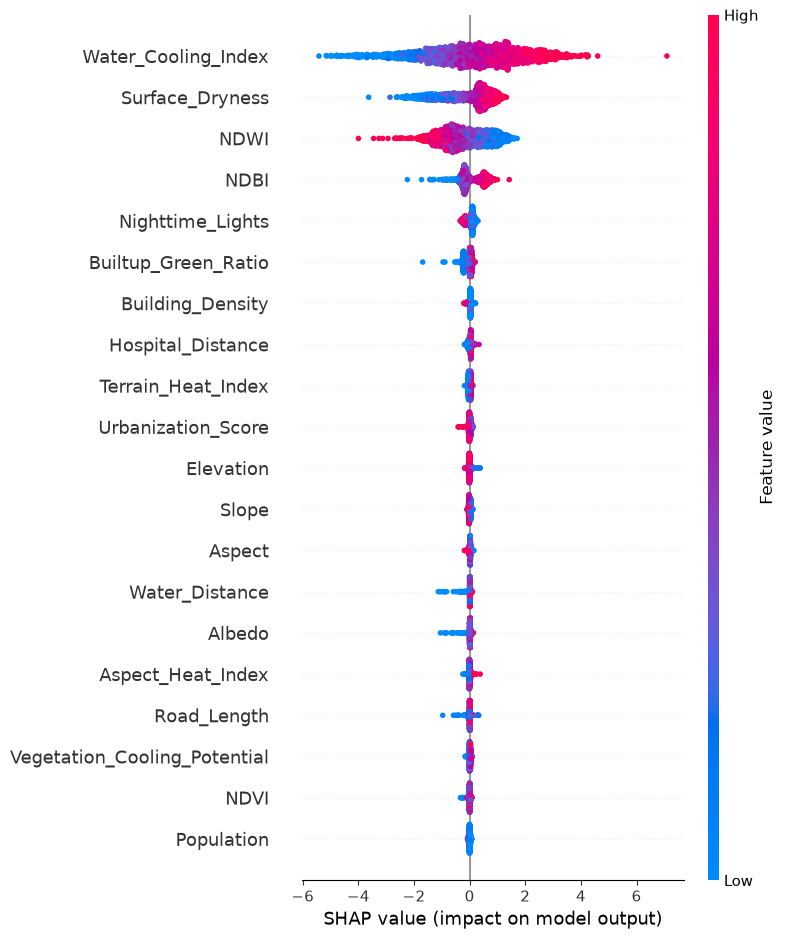

In [43]:
shap.summary_plot(shap_values, X_test)

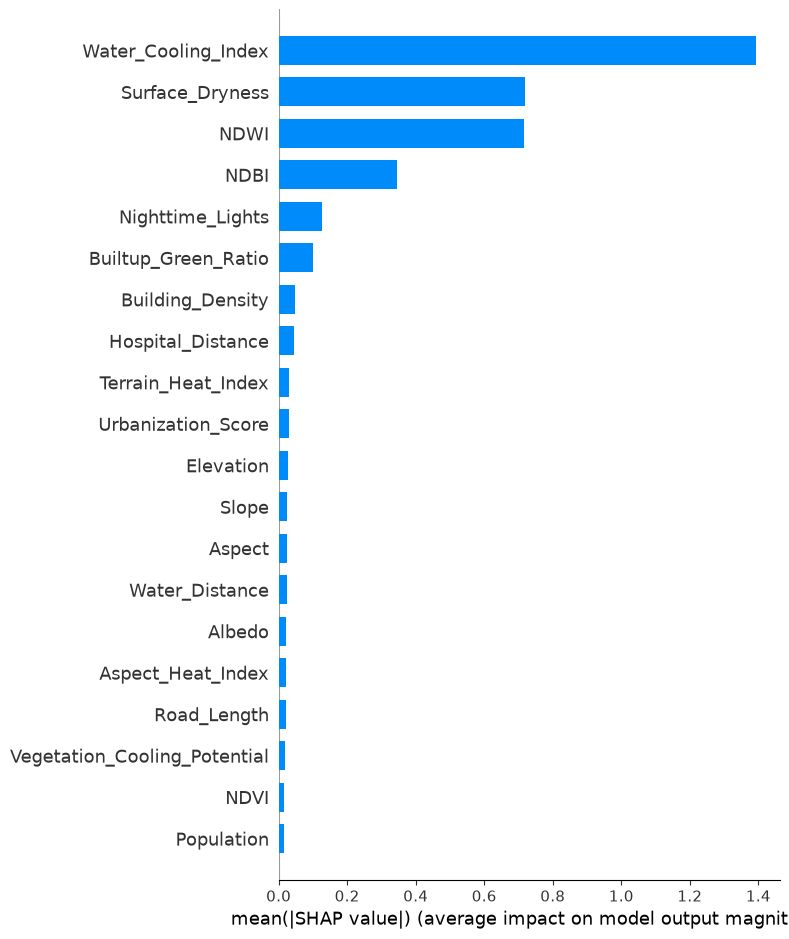

In [44]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

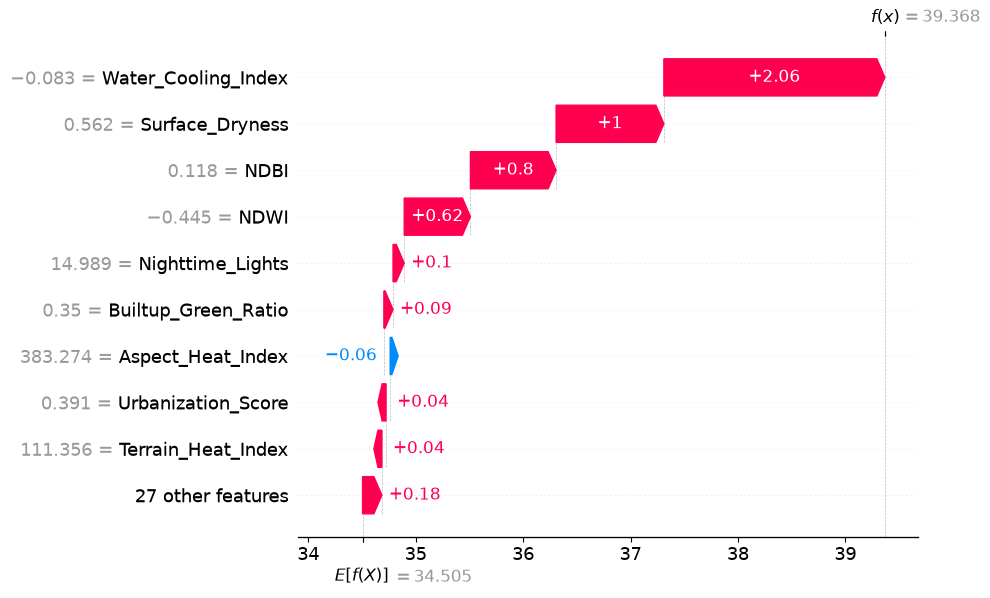

In [45]:
sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )
)

In [46]:
def simulate_changes(model, sample, changes):

    modified = sample.copy()

    for feature, value in changes.items():

        modified[feature] = value

    original = model.predict(sample)[0]

    new = model.predict(modified)[0]

    return original, new, original - new

In [47]:
sample = X_test.iloc[[0]]

In [48]:
current = best_model.predict(sample)[0]

print(current)

39.367558


In [49]:
modified = sample.copy()

modified["NDVI"] *= 1.20

In [50]:
best_model.predict(modified)

array([39.531166], dtype=float32)

In [51]:
modified = sample.copy()

modified["Water_Cooling_Index"] *= 1.20

In [52]:
modified = sample.copy()

modified["NDBI"] *= 0.80

In [53]:
recommendations = {

    "Increase Vegetation": {"NDVI": sample["NDVI"].values[0]*1.20},

    "Increase Water Cooling":
    {"Water_Cooling_Index":
        sample["Water_Cooling_Index"].values[0]*1.20},

    "Reduce Built-up":
    {"NDBI": sample["NDBI"].values[0]*0.80}
}

In [54]:
import pandas as pd

def recommend_interventions(model, sample):
    """
    Simulate different urban cooling interventions and rank them.
    """

    interventions = {
        "Increase Vegetation (NDVI +20%)": {
            "NDVI": sample["NDVI"].iloc[0] * 1.20
        },

        "Reduce Built-up (NDBI -20%)": {
            "NDBI": sample["NDBI"].iloc[0] * 0.80
        },

        "Increase Water Cooling (+20%)": {
            "Water_Cooling_Index": sample["Water_Cooling_Index"].iloc[0] * 1.20
        },

        "Reduce Surface Dryness (-20%)": {
            "Surface_Dryness": sample["Surface_Dryness"].iloc[0] * 0.80
        }
    }

    baseline = model.predict(sample)[0]

    results = []

    for name, changes in interventions.items():

        modified = sample.copy()

        for feature, value in changes.items():
            modified[feature] = value

        prediction = model.predict(modified)[0]

        results.append({
            "Intervention": name,
            "Original_LST": baseline,
            "New_LST": prediction,
            "Cooling_Effect": baseline - prediction
        })

    return pd.DataFrame(results).sort_values(
        by="Cooling_Effect",
        ascending=False
    )

In [55]:
sample = X_test.iloc[[0]]

recommendations = recommend_interventions(best_model, sample)

recommendations

,Intervention,Original_LST,New_LST,Cooling_Effect
2,Increase Water Cooling (+20%),39.367558,37.682388,1.685169
3,Reduce Surface Dryness (-20%),39.367558,38.670612,0.696945
1,Reduce Built-up (NDBI -20%),39.367558,39.449272,-0.081715
0,Increase Vegetation (NDVI +20%),39.367558,39.531166,-0.163609


In [56]:
for i in [0, 25, 100, 500]:
    print("=" * 60)
    print(f"Location {i}")
    print(recommend_interventions(best_model, X_test.iloc[[i]]))

Location 0
                      Intervention  Original_LST    New_LST  Cooling_Effect
2    Increase Water Cooling (+20%)     39.367558  37.682388        1.685169
3    Reduce Surface Dryness (-20%)     39.367558  38.670612        0.696945
1      Reduce Built-up (NDBI -20%)     39.367558  39.449272       -0.081715
0  Increase Vegetation (NDVI +20%)     39.367558  39.531166       -0.163609
Location 25
                      Intervention  Original_LST    New_LST  Cooling_Effect
2    Increase Water Cooling (+20%)     33.026646  31.005795        2.020851
3    Reduce Surface Dryness (-20%)     33.026646  32.763489        0.263157
1      Reduce Built-up (NDBI -20%)     33.026646  33.026646        0.000000
0  Increase Vegetation (NDVI +20%)     33.026646  33.032913       -0.006268
Location 100
                      Intervention  Original_LST    New_LST  Cooling_Effect
2    Increase Water Cooling (+20%)     33.164375  31.375200        1.789175
3    Reduce Surface Dryness (-20%)     33.164375  32

In [57]:
import joblib

joblib.dump(best_model, "HeatSatAI_XGBoost.pkl")
joblib.dump(explainer, "SHAP_Explainer.pkl")

feature_importance.to_csv("feature_importance.csv", index=False)

recommendations.to_csv("recommendations.csv", index=False)

In [58]:
results = X_test.copy()

results["Actual_LST"] = y_test.values
results["Predicted_LST"] = best_model.predict(X_test)
results["Error"] = results["Actual_LST"] - results["Predicted_LST"]

results.to_csv("prediction_results.csv", index=False)

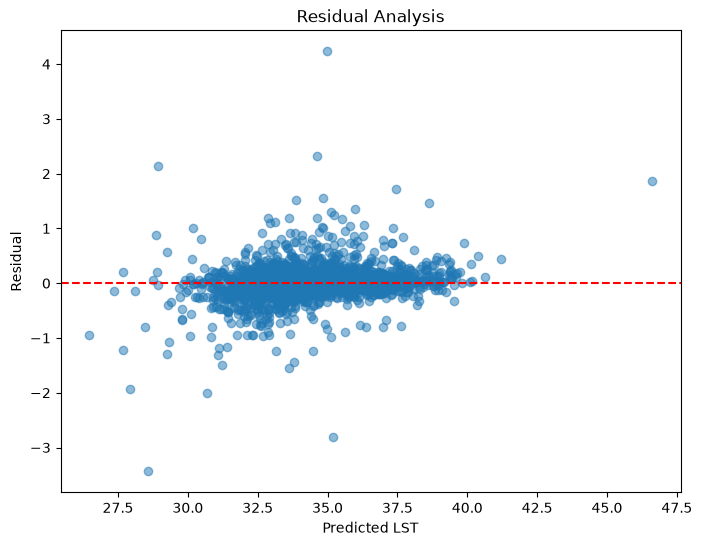

In [59]:
import matplotlib.pyplot as plt

pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(pred, y_test - pred, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted LST")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.show()

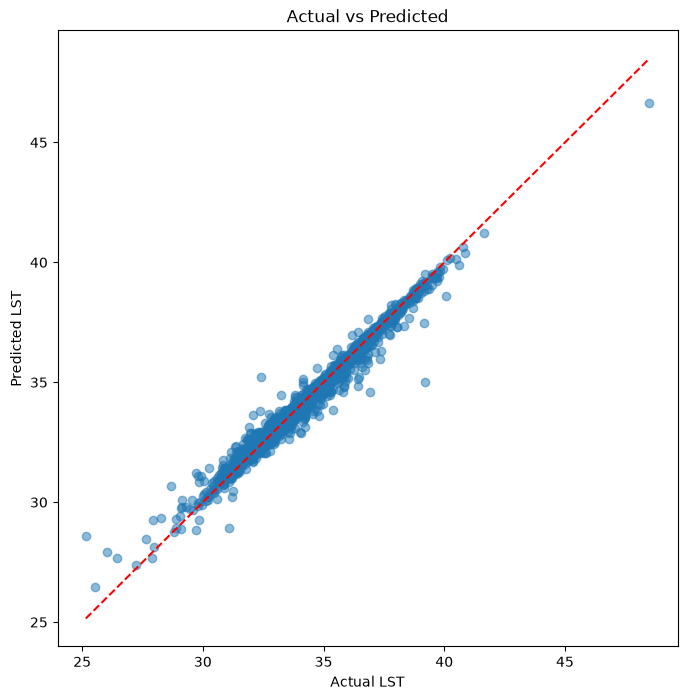

In [60]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost (untuned)",
        "Optimized XGBoost (spatial CV)"
    ],
    "RMSE": [
        rmse,
        np.sqrt(mean_squared_error(y_test, pred_xgb)),
        np.sqrt(mean_squared_error(y_test, pred))
    ],
    "MAE": [
        mae,
        mean_absolute_error(y_test, pred_xgb),
        mean_absolute_error(y_test, pred)
    ],
    "R2": [
        r2,
        r2_score(y_test, pred_xgb),
        r2_score(y_test, pred)
    ]
})

comparison
